In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import datetime
import scipy.stats
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.colors as cl
import matplotlib.dates as mdates
import matplotlib
import statsmodels.api as sm
#from statsmodels.regression.rolling import RollingOLS
import seaborn as sns


In [2]:
def decimal_year_to_datetime(decimal_year):
    year = decimal_year.astype(int)
    decimal_part = decimal_year - year
    start_of_year = pd.to_datetime([f'{y}-01-01' for y in year])
    seconds_in_year = (pd.to_datetime([f'{y+1}-01-01' for y in year]) - start_of_year).total_seconds()
    seconds = decimal_part * seconds_in_year
    return start_of_year + pd.to_timedelta(seconds, unit='s')

def datetime_to_decimal_year(datetime_):
    year = datetime_.year
    days = (datetime_.date() - datetime.date(year, 1,1)).days
    res = year + days/365.25
    return res

def FFT_res(x, si):
    n = len(x)
    x_FFT_shifted = np.fft.fftshift(np.fft.fft(x))
    x_FFT_freq_shifted = np.fft.fftshift(np.fft.fftfreq(n, d=si))
    return x_FFT_freq_shifted, x_FFT_shifted


def fft_noramlize(fft_res):
    n = len(fft_res)
    norm_fft = np.abs(fft_res)/(np.max(np.abs(fft_res)))
    return norm_fft

def line_fit(X,Y):
    P = np.polyfit(X,Y,1)
    dx = np.max(X) - np.min(X)
    X_new = np.array([np.min(X)-dx*0.05, np.max(X)+dx*0.05])
    Y_new = np.polyval(P, X_new)
    return X_new, Y_new, P

In [6]:
window_size = 3
window_size2 = 36

fred = pd.read_excel('../../../2025_08_22_FredsData-post2008/FredData_editedMemo.xlsx').dropna()
fred['d18o_pdb'] = -(fred['d18o']-20.91)/1.03091
fred[['d13c_ma','d18o_ma']] = fred[['d13c','d18o_pdb']].rolling(window_size, center=True).mean()
fred[['d13c_std','d18o_std']] = fred[['d13c','d18o_pdb']].rolling(10, center=True).std()
fred_resampled = fred.drop(fred.columns[3:], axis=1)
fred_resampled['age_dt'] = decimal_year_to_datetime(fred_resampled['decimal_year'])
fred_resampled.set_index('age_dt', inplace=True)
fred_resampled = fred_resampled.resample('30D').mean()
fred_resampled.interpolate(inplace=True)
fred_resampled

,decimal_year,d13c,d18o
age_dt,,,
1994-07-02,1994.500000,-1.902399,-5.428365
1994-08-01,1994.583333,-1.950000,-5.690000
1994-08-31,1994.666667,-2.344907,-5.521523
1994-09-30,1994.750000,-2.223590,-5.297143
1994-10-30,1994.833333,-2.089346,-5.113832
...,...,...,...
2011-09-01,2011.714286,-2.412638,-5.660454
2011-10-01,2011.785714,-2.053163,-5.602355
2011-10-31,2011.857143,-1.693687,-5.544257


In [9]:
tide = pd.read_csv('../../../2025_10_10_Fred-TideGauge/memo_edited.csv')
tide['age_dt'] = decimal_year_to_datetime(tide['Date'])
tide = tide.set_index('age_dt')
tide

,Date,Sea Level
age_dt,,
1968-07-02 00:00:00.000000000,1968.50000,7416.0
1968-08-01 11:58:14.591997869,1968.58333,7475.0
1968-08-31 23:56:29.184002928,1968.66666,NaN
1968-10-01 11:54:43.776000798,1968.74999,NaN
1968-10-31 23:52:58.367998667,1968.83332,NaN
...,...,...
2012-08-16 18:00:00.000000000,2012.62500,7265.0
2012-09-16 06:35:08.159999471,2012.70840,7291.0
2012-10-16 17:24:51.840000529,2012.79160,7287.0


Text(0, 0.5, 'Relative Sea Level (cm)')

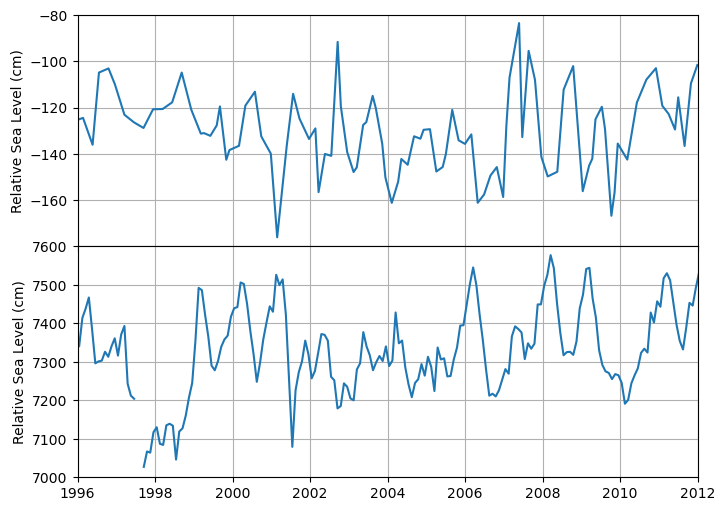

In [71]:
fred_resampled['sea_level'] = fred_resampled['d13c']*37.686-45.662

fig, axes = plt.subplots(2, figsize=(8,6), sharex=True, gridspec_kw={"hspace":0})

ax = axes[0]
ax.plot(fred_resampled['sea_level'], '')
ax.grid()
#yticks = ax.get_yticks()
#ax.set_yticklabels(yticks[3:])
ax.set_yticks(np.arange(-160,-60,20))
ax.set_ylim(-180, -80)
ax.set_ylabel('Relative Sea Level (cm)')



ax = axes[1]
ax.plot(tide['Sea Level'])
ax.set_xlim(datetime.datetime(1996,1,1), datetime.datetime(2012,1,1))
ax.grid()
#yticks = ax.get_yticks()
#ax.set_yticklabels(yticks[:-2])
ax.set_yticks(np.arange(7000, 7700, 100))
ax.set_ylim(7000,7600)
ax.set_ylabel('Relative Sea Level (cm)')


